# Learning Rate Schedules

## The idea
Instead of a **fixed** learning rate, a *schedule* changes η during training:
- **Big early** → fast progress when far from the minimum
- **Small late** → precise settling when close (big steps would overshoot/bounce)
- Often with **warmup** (start tiny, ramp up) for early stability

Common shapes: **warmup** (ramp up at start), **decay** (shrink over time, e.g. cosine),
and **warmup + decay** combined (the modern default for transformers).

## "But Adam already adapts the rate — why do we need a schedule too?"
They do **different jobs** and are used **together**:

| | Adam (adaptive rates) | Learning rate schedule |
|---|---|---|
| Adjusts... | each weight's step *relative to others* | the *overall* step scale |
| Based on... | *gradient size* (per weight) | *training progress* (time) |
| Handles... | "which weight moves how much, now" | "how big are steps overall, now" |

In the update `w ← w − η · (Adam's per-weight direction)`:
- **Adam** shapes the per-weight *direction* (relative balancing).
- **η** is the *global multiplier* — and the **schedule controls η over time**.

Adam balances weights against each other but does **not** shrink the *overall* step as you
near the minimum, nor ease in gently at the start (its early gradient estimates are unreliable).
The schedule does both. **Analogy:** Adam = power steering (per-wheel); schedule = gas/brake
(overall speed). You need both. Standard recipe: **AdamW + warmup + cosine decay.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simple bowl to show settling clearly: L = w^2, grad = 2w
def loss(w): return w**2
def grad(w): return 2*w

steps = 60; start = 9.0

def fixed(eta):
    w = start; hist=[loss(w)]; lrs=[eta]
    for _ in range(steps):
        w = w - eta*grad(w); hist.append(loss(w)); lrs.append(eta)
    return np.array(hist), np.array(lrs)

def scheduled(eta_max=0.9, warmup=8):
    w = start; hist=[loss(w)]; lrs=[]
    for t in range(steps):
        if t < warmup:
            eta = eta_max * (t+1)/warmup                    # warmup: ramp up
        else:
            prog = (t-warmup)/(steps-warmup)
            eta = eta_max * 0.5*(1+np.cos(np.pi*prog))       # cosine decay: ramp down
        lrs.append(eta)
        w = w - eta*grad(w); hist.append(loss(w))
    lrs.append(lrs[-1])
    return np.array(hist), np.array(lrs)

h_big,   lr_big   = fixed(0.9)      # too big at the end -> bounces, won't settle
h_small, lr_small = fixed(0.05)     # too small -> crawls
h_sched, lr_sched = scheduled(eta_max=0.9, warmup=8)

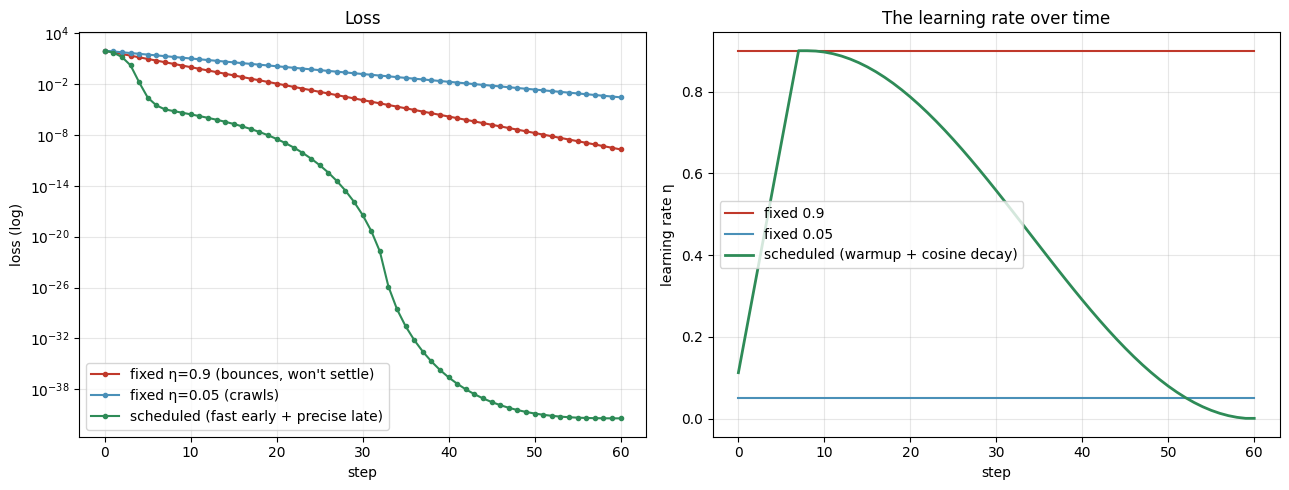

Final loss:
  fixed 0.9 : 1.90e-10 (bounces)
  fixed 0.05: 2.62e-04 (crawled)
  scheduled : 3.88e-42 (fast + precise)


In [2]:
fig, ax = plt.subplots(1,2, figsize=(13,5))

ax[0].plot(h_big,  'o-', color='#c0392b', ms=3, label="fixed η=0.9 (bounces, won't settle)")
ax[0].plot(h_small,'o-', color='#4a90b8', ms=3, label='fixed η=0.05 (crawls)')
ax[0].plot(h_sched,'o-', color='#2e8b57', ms=3, label='scheduled (fast early + precise late)')
ax[0].set_yscale('log'); ax[0].set_xlabel('step'); ax[0].set_ylabel('loss (log)')
ax[0].set_title('Loss'); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(lr_big,  color='#c0392b', label='fixed 0.9')
ax[1].plot(lr_small,color='#4a90b8', label='fixed 0.05')
ax[1].plot(lr_sched,color='#2e8b57', lw=2, label='scheduled (warmup + cosine decay)')
ax[1].set_xlabel('step'); ax[1].set_ylabel('learning rate η')
ax[1].set_title('The learning rate over time'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Final loss:")
print("  fixed 0.9 :", f"{h_big[-1]:.2e}", "(bounces)")
print("  fixed 0.05:", f"{h_small[-1]:.2e}", "(crawled)")
print("  scheduled :", f"{h_sched[-1]:.2e}", "(fast + precise)")

## Takeaway
- **Fixed too big** (red): fast at first but *bounces* near the minimum — can't settle finely.
- **Fixed too small** (blue): stable but *crawls* — wastes time.
- **Scheduled** (green): warmup for a stable start, then decay → fast early progress AND
  precise final settling. Reaches dramatically lower loss.

**Schedules vs Adam:** not competing — **complementary.** Adam adapts *per-weight* rates
(relative balancing); the schedule controls the *overall* rate over *time* (global pacing +
warmup stability). The standard modern setup uses **both**:

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=steps)
    # + warmup for the first few hundred steps (common in transformer fine-tuning)

You rarely design these — you pick a preset and set `warmup_steps`.